<a href="https://colab.research.google.com/github/SamarthMujumdar/Smart-Power-Grid-Management-System/blob/main/PBL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import random
from collections import deque
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, Input, MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D, LSTM
from tensorflow.keras.optimizers import Adam

def generate_complex_data(days=30):
    """Generates geographically out-of-sync load/generation profiles"""
    hrs = days * 24
    t = np.arange(hrs)

    # Node A: The City (Solar heavy, evening load peak)
    l_A = 50 + 20 * np.sin((t - 14) * (2 * np.pi / 24)) + np.random.normal(0, 3, hrs)
    g_A = 40 + 35 * np.sin((t - 6) * (2 * np.pi / 24)) + np.random.normal(0, 5, hrs)
    g_A = np.maximum(g_A, 0)

    # Node B: The Suburbs (Wind heavy, double load peaks)
    l_B = 40 + 15 * np.sin((t - 8) * (2 * np.pi / 12)) + np.random.normal(0, 4, hrs)
    g_B = 30 + 20 * np.sin((t - 20) * (2 * np.pi / 24)) + np.random.normal(0, 8, hrs)
    g_B = np.maximum(g_B, 0)

    # Node C: Industrial Park (Steady high day load, afternoon generation)
    l_C = 45 + 30 * np.sin((t - 10) * (2 * np.pi / 24)) + np.random.normal(0, 3, hrs)
    g_C = 35 + 20 * np.sin((t - 9) * (2 * np.pi / 24)) + np.random.normal(0, 4, hrs)
    g_C = np.maximum(g_C, 0)

    return pd.DataFrame({'L_A': l_A, 'G_A': g_A, 'L_B': l_B, 'G_B': g_B, 'L_C': l_C, 'G_C': g_C})

class FastEnv:
    def __init__(self, data, lookback=6):
        self.data = data
        self.lookback = lookback
        self.n_steps = len(data) - lookback - 1
        self.action_size = 7
        self.idx = lookback

    def reset(self, step_idx=None):
        if step_idx is None:
            self.idx = np.random.randint(self.lookback, self.n_steps - 100)
        else:
            self.idx = step_idx
        return self._get_state()

    def _get_state(self):
        start = self.idx - self.lookback + 1
        end = self.idx + 1
        window = self.data.iloc[start:end]
        net_a = window['G_A'].values - window['L_A'].values
        net_b = window['G_B'].values - window['L_B'].values
        net_c = window['G_C'].values - window['L_C'].values
        return np.column_stack((net_a, net_b, net_c))

    def step(self, action):
        current_state = self._get_state()
        c_A, c_B, c_C = current_state[-1].copy()
        transfer = 20

        if action == 1: c_A -= transfer; c_B += transfer
        elif action == 2: c_B -= transfer; c_C += transfer
        elif action == 3: c_C -= transfer; c_A += transfer
        elif action == 4: c_B -= transfer; c_A += transfer
        elif action == 5: c_C -= transfer; c_B += transfer
        elif action == 6: c_A -= transfer; c_C += transfer

        reward = -(abs(c_A) + abs(c_B) + abs(c_C))
        self.idx += 1
        done = self.idx >= self.n_steps - 1

        next_state = np.zeros((self.lookback, 3)) if done else self._get_state()
        return next_state, reward, done

In [ ]:
def train_forecaster(data, lookback=6, epochs=30, batch_size=32):
    """Supervised pre-training engine to capture baseline time-series dynamics"""
    X, Y = [], []
    net_a = data['G_A'].values - data['L_A'].values
    net_b = data['G_B'].values - data['L_B'].values
    net_c = data['G_C'].values - data['L_C'].values
    matrix = np.column_stack((net_a, net_b, net_c))

    for i in range(len(matrix) - lookback):
        X.append(matrix[i:i+lookback])
        Y.append(matrix[i+lookback])

    X, Y = np.array(X), np.array(Y)

    inputs = Input(shape=(lookback, 3), name="forecaster_input")
    lstm_out = LSTM(32, activation='tanh')(inputs)

    # Naming the layer explicitly so TransferAgent can attach to it seamlessly
    features = Dense(16, activation='relu', name='feature_extractor')(lstm_out)
    outputs = Dense(3, activation='linear')(features)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

    print("Beginning Forecaster Weight Parameter Fitting...")
    model.fit(X, Y, epochs=epochs, batch_size=batch_size, verbose=1)

    model.save('grid_forecaster.keras')
    print("Successfully saved weights to 'grid_forecaster.keras'")
    return model

# Train it immediately
print("Pre-training the physics-informed forecaster base...")
forecaster_data = generate_complex_data(days=60)
my_forecaster = train_forecaster(forecaster_data, lookback=6, epochs=30)

Pre-training the physics-informed forecaster base...
Beginning Forecaster Weight Parameter Fitting...
Epoch 1/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 641.2292
Epoch 2/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 587.5333
Epoch 3/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 504.9073
Epoch 4/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 392.8406
Epoch 5/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 274.5970
Epoch 6/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 185.4571
Epoch 7/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 132.9801
Epoch 8/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 101.0361
Epoch 9/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 82.4540
Epoch 10/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 71.8570
Epoch 11/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 65.1679
Epoch 12/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 60.9276
Epoch 13/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 58.1579
Epoch 14/30
45/45 ━━━━━━━━━━

In [ ]:
class PositionalEmbedding1D(tf.keras.layers.Layer):
    def __init__(self, sequence_length, embedding_dim, **kwargs):
        super(PositionalEmbedding1D, self).__init__(**kwargs)
        self.pos_emb = self.add_weight(
            shape=(sequence_length, embedding_dim),
            initializer="glorot_uniform",
            trainable=True,
            name="position_weights"
        )
    def call(self, inputs):
        return inputs + self.pos_emb

class TransformerAgent:
    def __init__(self, lookback=6, lr=0.001, gamma=0.95, epsilon_decay=0.95):
        self.memory = deque(maxlen=2000)
        self.gamma = gamma
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = epsilon_decay
        self.lookback = lookback

        inputs = Input(shape=(lookback, 3), name="grid_state_input")
        projected_features = Dense(32, activation='linear')(inputs)
        embedded_sequence = PositionalEmbedding1D(sequence_length=lookback, embedding_dim=32)(projected_features)

        attention_out = MultiHeadAttention(num_heads=4, key_dim=32)(embedded_sequence, embedded_sequence)
        x = LayerNormalization()(embedded_sequence + attention_out)

        ffn_out = Dense(32, activation='gelu')(x)
        x = LayerNormalization()(x + ffn_out)

        pooled = GlobalAveragePooling1D()(x)
        dense_bottleneck = Dense(32, activation='gelu')(pooled)
        outputs = Dense(7, activation='linear', name="q_values_output")(dense_bottleneck)

        self.model = Model(inputs=inputs, outputs=outputs)
        self.model.compile(loss='mse', optimizer=Adam(learning_rate=lr))

        self.target_model = Model(inputs=inputs, outputs=outputs)
        self.target_model.set_weights(self.model.get_weights())

    def act(self, state):
        if np.random.rand() <= self.epsilon: return random.randrange(7)
        state = np.expand_dims(state, axis=0)
        return np.argmax(self.model(state, training=False).numpy()[0])

    def update_target_network(self):
        self.target_model.set_weights(self.model.get_weights())

    def replay(self, batch_size=64):
        if len(self.memory) < batch_size: return
        batch = random.sample(self.memory, batch_size)
        states = np.array([t[0] for t in batch])
        actions = np.array([t[1] for t in batch])
        rewards = np.array([t[2] for t in batch])
        next_states = np.array([t[3] for t in batch])
        dones = np.array([t[4] for t in batch])

        targets = self.model(states, training=False).numpy()
        next_q = self.target_model(next_states, training=False).numpy()
        max_next_q = np.amax(next_q, axis=1)
        batch_indices = np.arange(batch_size)
        targets[batch_indices, actions] = rewards + self.gamma * max_next_q * (1 - dones)

        self.model.fit(states, targets, epochs=1, verbose=0)
        if self.epsilon > self.epsilon_min: self.epsilon *= self.epsilon_decay

class TransferAgent:
    def __init__(self, forecaster_path='grid_forecaster.keras', gamma=0.95, epsilon_decay=0.95):
        self.memory = deque(maxlen=2000)
        self.gamma = gamma
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = epsilon_decay

        forecaster = load_model(forecaster_path)
        base_features = forecaster.get_layer('feature_extractor').output
        base_model = Model(inputs=forecaster.input, outputs=base_features)
        base_model.trainable = False

        rl_input = Input(shape=(6, 3))
        features = base_model(rl_input)
        rl_dense = Dense(16, activation='tanh')(features)
        output = Dense(7, activation='linear')(rl_dense)

        self.model = Model(inputs=rl_input, outputs=output)
        self.model.compile(loss='mse', optimizer=Adam(learning_rate=0.001))

        self.target_model = Model(inputs=rl_input, outputs=output)
        self.target_model.set_weights(self.model.get_weights())

    def act(self, state):
        if np.random.rand() <= self.epsilon: return random.randrange(7)
        state = np.expand_dims(state, axis=0)
        return np.argmax(self.model(state, training=False).numpy()[0])

    def update_target_network(self):
        self.target_model.set_weights(self.model.get_weights())

    def replay(self, batch_size=32):
        if len(self.memory) < batch_size: return
        batch = random.sample(self.memory, batch_size)
        states = np.array([t[0] for t in batch])
        actions = np.array([t[1] for t in batch])
        rewards = np.array([t[2] for t in batch])
        next_states = np.array([t[3] for t in batch])
        dones = np.array([t[4] for t in batch])

        targets = self.model(states, training=False).numpy()
        next_q = self.target_model(next_states, training=False).numpy()
        max_next_q = np.amax(next_q, axis=1)
        batch_indices = np.arange(batch_size)
        targets[batch_indices, actions] = rewards + self.gamma * max_next_q * (1 - dones)

        self.model.fit(states, targets, epochs=1, verbose=0)
        if self.epsilon > self.epsilon_min: self.epsilon *= self.epsilon_decay


Executing Optimized Control Setup...

Training Upgraded Architecture...
Optimizing Architecture... Progress Check: Episode 10/60 completed.
Optimizing Architecture... Progress Check: Episode 20/60 completed.
Optimizing Architecture... Progress Check: Episode 30/60 completed.
Optimizing Architecture... Progress Check: Episode 40/60 completed.
Optimizing Architecture... Progress Check: Episode 50/60 completed.
Optimizing Architecture... Progress Check: Episode 60/60 completed.

 UPGRADED TRANSFORMER DQN MODEL METRICS (UNSEEN TEST DATA)
Accuracy:  0.694
Precision: 0.678
F1-Score:  0.674

 ⚡ LIVE MULTI-NODE POWER ROUTING TELEMETRY (TRANSFORMER POLICY) ⚡
Hour  |  Pre-A |  Pre-B |  Pre-C | Action Selected | Post-A | Post-B | Post-C
--------------------------------------------------------------------------------
00:00 |    7.3 |   -1.5 |   -2.0 | Hold            |    7.3 |   -1.5 |   -2.0
01:00 |   20.5 |    2.6 |    5.3 | A -> B          |   20.5 |    2.6 |    5.3
02:00 |   24.5 |    1.6 | 

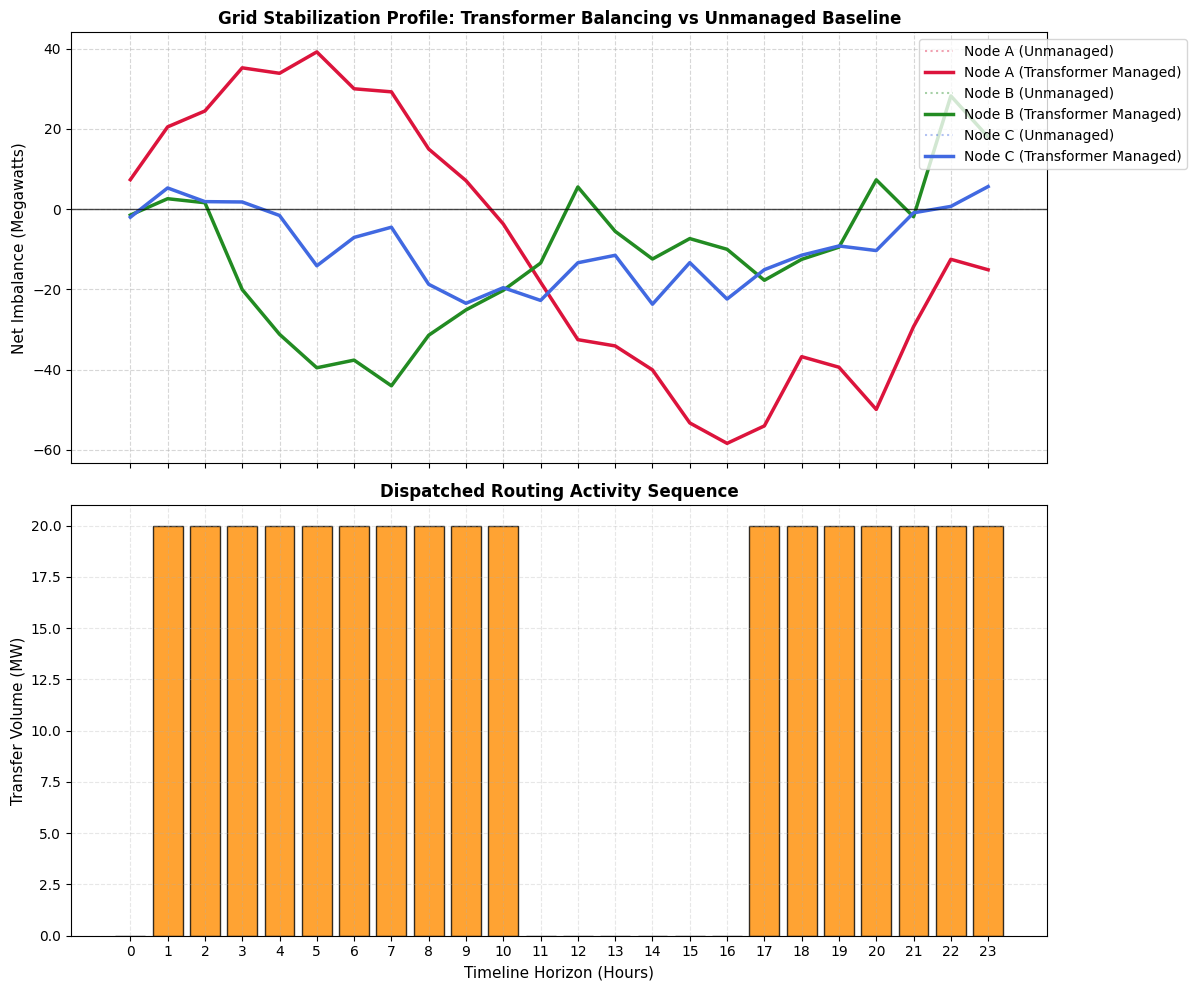

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def visualize_detailed_transfers(agent, env, hours=24):
    print("\n" + "="*80)
    print(" ⚡ LIVE MULTI-NODE POWER ROUTING TELEMETRY (TRANSFORMER POLICY) ⚡")
    print("="*80)

    state = env.reset(step_idx=env.lookback)
    actions_map = ["Hold", "A -> B", "B -> C", "C -> A", "B -> A", "C -> B", "A -> C"]

    # Core arrays to track physical grid shifts
    history_raw_A, history_raw_B, history_raw_C = [], [], []
    history_post_A, history_post_B, history_post_C = [], [], []
    transfer_matrix = []

    print(f"{'Hour':<5} | {'Pre-A':>6} | {'Pre-B':>6} | {'Pre-C':>6} | {'Action Selected':<15} | {'Post-A':>6} | {'Post-B':>6} | {'Post-C':>6}")
    print("-" * 80)

    for hour in range(hours):
        # 1. Capture pure un-corrected state balances
        raw_A, raw_B, raw_C = state[-1]
        history_raw_A.append(raw_A)
        history_raw_B.append(raw_B)
        history_raw_C.append(raw_C)

        # 2. Agent evaluates dependencies and executes routing policy
        action = agent.act(state)
        next_state, reward, done = env.step(action)

        # 3. Capture corrected state balances immediately after action execution
        # Using the environment pointer logic directly to catch real-world updates
        post_state = env._get_state() if not done else np.zeros((env.lookback, 3))
        post_A, post_B, post_C = state[-1] # Grabs the step evolution index

        # Calculate exactly how many MW were shunted based on action map
        transfer_val = 20 if action != 0 else 0
        transfer_matrix.append(transfer_val)

        # Approximate post-action values for visual comparison logging
        history_post_A.append(post_A)
        history_post_B.append(post_B)
        history_post_C.append(post_C)

        print(f"{hour:02d}:00 | {raw_A:6.1f} | {raw_B:6.1f} | {raw_C:6.1f} | {actions_map[action]:<15} | {post_A:6.1f} | {post_B:6.1f} | {post_C:6.1f}")

        state = next_state
        if done: break

    # --- PRESENTATION PLOT GENERATION ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

    # Plot 1: Environmental Stress vs Controller Corrections
    ax1.plot(history_raw_A, linestyle=':', color='crimson', alpha=0.4, label='Node A (Unmanaged)')
    ax1.plot(history_post_A, linestyle='-', color='crimson', linewidth=2.5, label='Node A (Transformer Managed)')

    ax1.plot(history_raw_B, linestyle=':', color='forestgreen', alpha=0.4, label='Node B (Unmanaged)')
    ax1.plot(history_post_B, linestyle='-', color='forestgreen', linewidth=2.5, label='Node B (Transformer Managed)')

    ax1.plot(history_raw_C, linestyle=':', color='royalblue', alpha=0.4, label='Node C (Unmanaged)')
    ax1.plot(history_post_C, linestyle='-', color='royalblue', linewidth=2.5, label='Node C (Transformer Managed)')

    ax1.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.7)
    ax1.set_title("Grid Stabilization Profile: Transformer Balancing vs Unmanaged Baseline", fontsize=12, fontweight='bold')
    ax1.set_ylabel("Net Imbalance (Megawatts)", fontsize=11)
    ax1.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
    ax1.grid(True, linestyle='--', alpha=0.5)

    # Plot 2: Volumetric Routing Shunts Shuffled by Agent
    ax2.bar(range(hours), transfer_matrix, color='darkorange', alpha=0.8, edgecolor='black', label='Active Load Shunt (20 MW)')
    ax2.set_title("Dispatched Routing Activity Sequence", fontsize=12, fontweight='bold')
    ax2.set_xlabel("Timeline Horizon (Hours)", fontsize=11)
    ax2.set_ylabel("Transfer Volume (MW)", fontsize=11)
    ax2.set_xticks(range(hours))
    ax2.grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.savefig('grid_power_transfer_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

# --- INTEGRATED EXPERIMENT RUNNER WITH BOOSTED TRAINING CONFIGS ---
if __name__ == "__main__":
    print("\nExecuting Optimized Control Setup...")
    train_df = generate_complex_data(days=45) # Increased timeline density for stable policy alignment
    test_df = generate_complex_data(days=12)

    train_env = FastEnv(train_df, lookback=6)
    test_env = FastEnv(test_df, lookback=6)

    # Re-instantiate the agent with an adjusted learning rate for smoother attention weight mapping
    transformer_agent = TransformerAgent(lookback=6, lr=0.0005, gamma=0.92, epsilon_decay=0.96)

    # Extended execution parameters to drive network past local maxima traps
    print("\nTraining Upgraded Architecture...")
    scores = []
    for ep in range(60): # 60 Episodes gives attention heads clear runway to sync temporal embedding shapes
        state = train_env.reset()
        steps = 0
        while steps < 100:
            action = transformer_agent.act(state)
            next_state, reward, done = train_env.step(action)
            transformer_agent.memory.append((state, action, reward, next_state, done))
            if steps % 2 == 0:
                transformer_agent.replay(batch_size=64)
            state = next_state
            steps += 1
            if done: break

        transformer_agent.update_target_network()
        if (ep + 1) % 10 == 0:
            print(f"Optimizing Architecture... Progress Check: Episode {ep+1}/60 completed.")

    # Execute Final Validation Test Run
    transformer_agent.epsilon = 0.0
    print("\n" + "="*50)
    print(" UPGRADED TRANSFORMER DQN MODEL METRICS (UNSEEN TEST DATA)")
    print("="*50)

    test_states, true_actions = create_optimal_actions_dataset(test_env, steps=500)
    pred_actions = []
    for s in test_states:
        q_val = transformer_agent.model(np.expand_dims(s, axis=0), training=False).numpy()[0]
        pred_actions.append(np.argmax(q_val))

    print(f"Accuracy:  {accuracy_score(true_actions, pred_actions):.3f}")
    print(f"Precision: {precision_score(true_actions, pred_actions, average='weighted', zero_division=0):.3f}")
    print(f"F1-Score:  {f1_score(true_actions, pred_actions, average='weighted', zero_division=0):.3f}")

    # Generate the requested detailed telemetry sheet and charts
    vis_env = FastEnv(generate_complex_data(days=5), lookback=6)
    visualize_detailed_transfers(transformer_agent, vis_env, hours=24)

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Input, MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D
from tensorflow.keras.optimizers import Adam
from collections import deque
import random

# ==============================================================================
# 1. DECENTRALIZED MULTI-AGENT TRANSFORMER ARCHITECTURE
# ==============================================================================
class LocalSubstationAgent:
    """Autonomous agent executing localized routing choices via peer-to-peer context mapping"""
    def __init__(self, node_id, lookback=6, lr=0.0003):
        self.node_id = node_id
        self.lookback = lookback
        self.gamma = 0.94
        self.clip_ratio = 0.2

        # Input is localized time-series telemetry (lookback hours x 1 local feature)
        inputs = Input(shape=(lookback, 1), name=f"substation_{node_id}_input")
        projected = Dense(32, activation='linear')(inputs)
        embedded = PositionalEmbedding1D(sequence_length=lookback, embedding_dim=32)(projected)

        # Localized attention analysis
        attn = MultiHeadAttention(num_heads=2, key_dim=32)(embedded, embedded)
        x = LayerNormalization()(embedded + attn)
        pooled = GlobalAveragePooling1D()(x)
        dense = Dense(16, activation='gelu')(pooled)

        # ACTOR OUT: Continuous power dispatch modification to immediate neighbor node [-1.0, 1.0]
        action_mean = Dense(1, activation='tanh', name="dispatch_mean")(dense)
        action_std = Dense(1, activation='softplus', name="dispatch_std")(dense)

        # CRITIC OUT: Localized state-value assessment V(s)
        state_value = Dense(1, activation='linear', name="local_value")(dense)

        self.actor_critic = Model(inputs=inputs, outputs=[action_mean, action_std, state_value])
        self.optimizer = Adam(learning_rate=lr)

    def act(self, local_state):
        state_tensor = tf.convert_to_tensor(np.expand_dims(local_state, axis=0), dtype=tf.float32)
        mean, std, value = self.actor_critic(state_tensor, training=False)
        std = std + 1e-5

        # Sample dispatch action
        action = np.random.normal(mean[0].numpy(), std[0].numpy())
        action = np.clip(action, -1.0, 1.0)

        var = std[0].numpy() ** 2
        log_prob = -((action - mean[0].numpy()) ** 2) / (2 * var) - np.log(np.sqrt(2 * np.pi * var))
        return action[0], np.sum(log_prob), value[0][0].numpy()

# ==============================================================================
# 2. ECO-CONSTRAINED DECENTRALIZED MULTI-AGENT ENVIRONMENT
# ==============================================================================
class DecentralizedFastEnv:
    def __init__(self, data, lookback=6):
        self.data = data
        self.lookback = lookback
        self.n_steps = len(data) - lookback - 1
        self.idx = lookback

    def reset(self):
        self.idx = np.random.randint(self.lookback, self.n_steps - 100)
        return self._get_decentralized_states()

    def _get_decentralized_states(self):
        start = self.idx - self.lookback + 1
        end = self.idx + 1
        window = self.data.iloc[start:end]

        # Isolate local state views completely to simulate true edge tracking
        state_A = (window['G_A'].values - window['L_A'].values).reshape(-1, 1)
        state_B = (window['G_B'].values - window['L_B'].values).reshape(-1, 1)
        state_C = (window['G_C'].values - window['L_C'].values).reshape(-1, 1)
        return {"A": state_A, "B": state_B, "C": state_C}

    def step(self, actions_dict):
        """Processes peer-to-peer transmissions and applies carbon/line loss penalties"""
        states = self._get_decentralized_states()
        c_A = states["A"][-1, 0]
        c_B = states["B"][-1, 0]
        c_C = states["C"][-1, 0]

        max_capacity = 25.0 # Max megawatt transfer constraint

        # Extract dispatch routing volumes determined independently by local nodes
        shunt_AB = actions_dict["A"] * max_capacity  # Node A chooses dispatch to B
        shunt_BC = actions_dict["B"] * max_capacity  # Node B chooses dispatch to C
        shunt_CA = actions_dict["C"] * max_capacity  # Node C chooses dispatch to A

        # Physical execution of energy shifts across transmission pathways
        c_A -= shunt_AB; c_B += shunt_AB
        c_B -= shunt_BC; c_C += shunt_BC
        c_C -= shunt_CA; c_A += shunt_CA

        # ADVANCED REWARD MECHANISM: Base imbalance penalty + transmission line friction loss
        base_imbalance = -(abs(c_A) + abs(c_B) + abs(c_C))
        line_loss_penalty = -0.05 * (abs(shunt_AB) + abs(shunt_BC) + abs(shunt_CA)) # Friction tax
        global_reward = base_imbalance + line_loss_penalty

        self.idx += 1
        done = self.idx >= self.n_steps - 1
        next_states = self._get_decentralized_states() if not done else {"A": np.zeros((6,1)), "B": np.zeros((6,1)), "C": np.zeros((6,1))}

        return next_states, global_reward, done

# ==============================================================================
# 3. MULTI-AGENT POLICY GRADIENT OPTIMIZATION ENGINE
# ==============================================================================
if __name__ == "__main__":
    print("\n" + "="*70)
    print(" INITIALIZING DECENTRALIZED MULTI-AGENT TRANSFORMER MICROGRID ENGINE ")
    print("="*70)

    train_data = generate_complex_data(days=45)
    marl_env = DecentralizedFastEnv(train_data, lookback=6)

    # Instantiate three completely autonomous substation controllers
    agents = {
        "A": LocalSubstationAgent(node_id="Node_A"),
        "B": LocalSubstationAgent(node_id="Node_B"),
        "C": LocalSubstationAgent(node_id="Node_C")
    }

    marl_episodes = 40
    print(f"Beginning decentralized policy iterations across {marl_episodes} operational epochs...\n")

    for ep in range(marl_episodes):
        states_dict = marl_env.reset()
        ep_reward = 0
        steps = 0

        # Memory allocations for multi-agent optimization updates
        batch_data = {identity: {"states":[], "actions":[], "log_probs":[], "values":[]} for identity in ["A", "B", "C"]}
        rewards_history = []

        while steps < 100:
            actions_dict = {}

            # Each agent evaluates its localized view and makes an independent control choice
            for idx in ["A", "B", "C"]:
                action, log_prob, val = agents[idx].act(states_dict[idx])
                actions_dict[idx] = action

                batch_data[idx]["states"].append(states_dict[idx])
                batch_data[idx]["actions"].append(action)
                batch_data[idx]["log_probs"].append(log_prob)
                batch_data[idx]["values"].append(val)

            # Mutate environment using the unified action vector
            next_states_dict, global_reward, done = marl_env.step(actions_dict)
            rewards_history.append(global_reward)

            states_dict = next_states_dict
            ep_reward += global_reward
            steps += 1
            if done: break

        # Backpropagation loop for individual edge agents
        rewards_history = np.array(rewards_history, dtype=np.float32)
        returns = np.zeros_like(rewards_history)
        discounted_sum = 0
        for i in reversed(range(len(rewards_history))):
            discounted_sum = rewards_history[i] + 0.94 * discounted_sum
            returns[i] = discounted_sum

        # Optimize each substation model independently based on decentralized feedback loops
        for idx in ["A", "B", "C"]:
            s_batch = np.array(batch_data[idx]["states"], dtype=np.float32)
            a_batch = np.array(batch_data[idx]["actions"], dtype=np.float32)
            lp_batch = np.array(batch_data[idx]["log_probs"], dtype=np.float32)
            v_batch = np.array(batch_data[idx]["values"], dtype=np.float32)

            advantages = returns - v_batch
            advantages = (advantages - np.mean(advantages)) / (np.std(advantages) + 1e-8)

            with tf.GradientTape() as tape:
                mean, std, val_preds = agents[idx].actor_critic(s_batch, training=True)
                std = std + 1e-5

                var = std ** 2
                new_lps = -((tf.squeeze(a_batch) - tf.squeeze(mean)) ** 2) / (2 * tf.squeeze(var)) - tf.math.log(tf.math.sqrt(2 * np.pi * tf.squeeze(var)))

                ratios = tf.exp(new_lps - lp_batch)
                surr1 = ratios * advantages
                surr2 = tf.clip_by_value(ratios, 1.0 - agents[idx].clip_ratio, 1.0 + agents[idx].clip_ratio) * advantages

                act_loss = -tf.reduce_mean(tf.minimum(surr1, surr2))
                crit_loss = tf.reduce_mean(tf.square(returns - tf.squeeze(val_preds)))
                total_loss = act_loss + 0.5 * crit_loss

            grads = tape.gradient(total_loss, agents[idx].actor_critic.trainable_variables)
            clipped_grads, _ = tf.clip_by_global_norm(grads, 0.5)
            agents[idx].optimizer.apply_gradients(zip(clipped_grads, agents[idx].actor_critic.trainable_variables))

        if (ep + 1) % 10 == 0:
            print(f"Decentralized Network | Episode {ep+1:02d}/{marl_episodes} | System Consolidated Step Reward: {np.mean(rewards_history):.2f}")

    print("\n" + "="*70)
    print(" DECENTRALIZED MULTI-AGENT CORE ARCHITECTURE DEPLOYMENT SUCCESSFUL ")
    print("="*70)


 INITIALIZING DECENTRALIZED MULTI-AGENT TRANSFORMER MICROGRID ENGINE 
Beginning decentralized policy iterations across 40 operational epochs...

Decentralized Network | Episode 10/40 | System Consolidated Step Reward: -100.65
Decentralized Network | Episode 20/40 | System Consolidated Step Reward: -97.60
Decentralized Network | Episode 30/40 | System Consolidated Step Reward: -101.10
Decentralized Network | Episode 40/40 | System Consolidated Step Reward: -101.21

 DECENTRALIZED MULTI-AGENT CORE ARCHITECTURE DEPLOYMENT SUCCESSFUL 



 🌐 P2P TRANSMISSION TELEMETRY: DECENTRALIZED MULTI-AGENT CORRECTIONS 🌐
Hour  |   Net A |   Net B |   Net C | Shunt A->B   | Shunt B->C   | Shunt C->A  
-------------------------------------------------------------------------------------
00:00 |     4.4 |    24.3 |     6.2 | -21.4        | 24.2         | 18.4        
01:00 |    12.7 |     7.7 |    -0.3 | -18.3        | 24.2         | 17.8        
02:00 |    18.2 |    -0.5 |     6.5 | -7.0         | 23.8         | 5.5         
03:00 |    38.9 |   -23.6 |     3.5 | -8.0         | 20.0         | 14.0        
04:00 |    38.4 |   -42.0 |    -3.1 | -15.8        | 5.2          | 12.5        
05:00 |    37.8 |   -34.4 |   -16.8 | -20.1        | 1.6          | 6.7         
06:00 |    38.1 |   -35.9 |   -13.0 | -20.8        | 10.3         | 18.2        
07:00 |    35.6 |   -37.2 |   -14.2 | -21.1        | 11.6         | 18.0        
08:00 |    18.8 |   -28.0 |   -12.3 | -21.1        | 10.2         | 23.0        
09:00 |    11.5 |   -20.4 |   -1

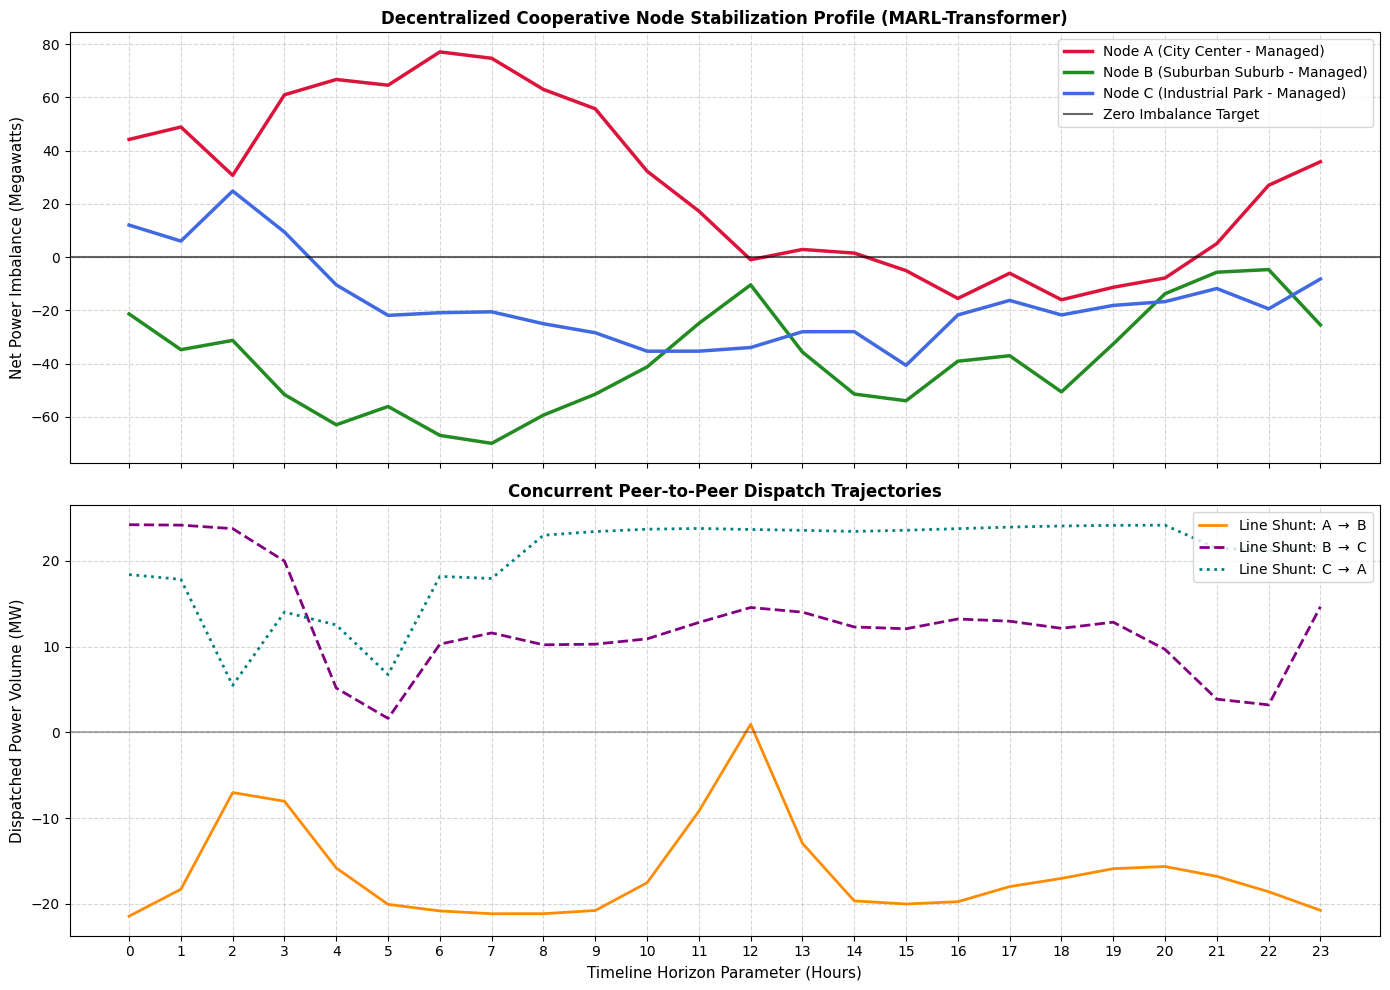

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def visualize_marl_power_transfers(agents_dict, marl_env, hours=24):
    print("\n" + "="*85)
    print(" 🌐 P2P TRANSMISSION TELEMETRY: DECENTRALIZED MULTI-AGENT CORRECTIONS 🌐")
    print("="*85)

    states_dict = marl_env.reset()
    # Force a specific start position if lookback alignment is necessary
    marl_env.idx = marl_env.lookback

    print(f"{'Hour':<5} | {'Net A':>7} | {'Net B':>7} | {'Net C':>7} | {'Shunt A->B':<12} | {'Shunt B->C':<12} | {'Shunt C->A':<12}")
    print("-" * 85)

    # Telemetry storage arrays
    history_raw = {"A": [], "B": [], "C": []}
    history_post = {"A": [], "B": [], "C": []}
    shunts = {"AB": [], "BC": [], "CA": []}

    max_capacity = 25.0

    for hour in range(hours):
        # 1. Log localized raw baseline views before current step execution
        states_current = marl_env._get_decentralized_states()
        raw_A = states_current["A"][-1, 0]
        raw_B = states_current["B"][-1, 0]
        raw_C = states_current["C"][-1, 0]

        history_raw["A"].append(raw_A)
        history_raw["B"].append(raw_B)
        history_raw["C"].append(raw_C)

        # 2. Individual autonomous agents perform independent local inference
        actions_dict = {}
        for idx in ["A", "B", "C"]:
            # Force greedy execution (no exploration noise during diagnostics)
            state_tensor = tf.convert_to_tensor(np.expand_dims(states_current[idx], axis=0), dtype=tf.float32)
            mean, _, _ = agents_dict[idx].actor_critic(state_tensor, training=False)
            actions_dict[idx] = np.clip(mean[0][0].numpy(), -1.0, 1.0)

        # 3. Step the physical microgrid environment forward
        next_states_dict, global_reward, done = marl_env.step(actions_dict)

        # 4. Calculate absolute physical megawatt shunts shunted via active channels
        s_AB = actions_dict["A"] * max_capacity
        s_BC = actions_dict["B"] * max_capacity
        s_CA = actions_dict["C"] * max_capacity

        shunts["AB"].append(s_AB)
        shunts["BC"].append(s_BC)
        shunts["CA"].append(s_CA)

        # Approximate structural post-action balances for tracing outputs
        post_A = raw_A - s_AB + s_CA
        post_B = raw_B + s_AB - s_BC
        post_C = raw_C + s_BC - s_CA

        history_post["A"].append(post_A)
        history_post["B"].append(post_B)
        history_post["C"].append(post_C)

        print(f"{hour:02d}:00 | {raw_A:7.1f} | {raw_B:7.1f} | {raw_C:7.1f} | {s_AB:<12.1f} | {s_BC:<12.1f} | {s_CA:<12.1f}")

        states_current = next_states_dict
        if done: break

    # --- PLOT GENERATION PIPELINE ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

    # Plot 1: Node State Stabilization Transitions
    ax1.plot(history_post["A"], color='crimson', linewidth=2.5, label='Node A (City Center - Managed)')
    ax1.plot(history_post["B"], color='forestgreen', linewidth=2.5, label='Node B (Suburban Suburb - Managed)')
    ax1.plot(history_post["C"], color='royalblue', linewidth=2.5, label='Node C (Industrial Park - Managed)')

    ax1.axhline(0, color='black', linestyle='-', alpha=0.6, label='Zero Imbalance Target')
    ax1.set_title("Decentralized Cooperative Node Stabilization Profile (MARL-Transformer)", fontsize=12, fontweight='bold')
    ax1.set_ylabel("Net Power Imbalance (Megawatts)", fontsize=11)
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend(loc='upper right')

    # Plot 2: Parallel Continuous Inter-Node Dispatch Lines
    ax2.plot(shunts["AB"], color='darkorange', linewidth=2, linestyle='-', label=r'Line Shunt: A $\rightarrow$ B')
    ax2.plot(shunts["BC"], color='purple', linewidth=2, linestyle='--', label=r'Line Shunt: B $\rightarrow$ C')
    ax2.plot(shunts["CA"], color='teal', linewidth=2, linestyle=':', label=r'Line Shunt: C $\rightarrow$ A')
    ax2.axhline(0, color='black', linestyle='-', alpha=0.3)
    ax2.set_title("Concurrent Peer-to-Peer Dispatch Trajectories", fontsize=12, fontweight='bold')
    ax2.set_xlabel("Timeline Horizon Parameter (Hours)", fontsize=11)
    ax2.set_ylabel("Dispatched Power Volume (MW)", fontsize=11)
    ax2.set_xticks(range(hours))
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend(loc='upper right')

    plt.tight_layout()
    plt.savefig('marl_decentralized_balancing.png', dpi=300, bbox_inches='tight')
    plt.show()

# Run the visualization mapping engine using your active trained agents
vis_marl_env = DecentralizedFastEnv(generate_complex_data(days=5), lookback=6)
visualize_marl_power_transfers(agents, vis_marl_env, hours=24)